# Sustainability comparison — generator experiments

Compares the energy, CO2 and wall-clock cost of the diffuser/generator experiments from the
canonical sustainability registry (`results/5_sustainability/canonical_events.jsonl`). Classifier
consumption is out of scope. CodeCarbon figures are estimates, not wall-socket measurements.

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'configs').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/utility'))

import pandas as pd
import matplotlib.pyplot as plt
from sustainability_registry import (
    load_events, deduplicate_canonical_events, actual_vs_canonical,
)

EVENTS = ROOT / 'results/5_sustainability/canonical_events.jsonl'
FIGURES = ROOT / 'results/5_sustainability/figures'
FIGURES.mkdir(parents=True, exist_ok=True)

events = load_events(EVENTS)
canonical = deduplicate_canonical_events(events)
frame = pd.DataFrame(canonical)
# Fold the experiment-08 step-count sweep variants into their base generator.
frame['generator'] = frame['experiment_id'].str.replace(r'_sampling_.*$', '', regex=True)
for column in ('energy_kwh', 'co2_kg', 'elapsed_seconds', 'num_images'):
    frame[column] = pd.to_numeric(frame[column], errors='coerce')
# Generator experiments are the ones that train or sample a diffuser.
generator_ids = sorted(frame.loc[frame['phase'].isin(['generator_training', 'generation']), 'generator'].unique())
diffusers = frame[frame['generator'].isin(generator_ids)].copy()
{'canonical_events': len(canonical), 'generator_experiments': generator_ids}

{'canonical_events': 174,
 'generator_experiments': ['01_sd21_baseline_50steps',
  '03_sd21_vae_finetuned',
  '04_sd21_lora',
  '06_ldm_extra1361_fromscratch',
  '07_ldm_sdvae_extra1361',
  '08_ldm_v3_sdvae_fromscratch']}

## 1. Cost per generator experiment

In [2]:
totals = (diffusers.groupby('generator')
          .agg(energy_kwh=('energy_kwh', 'sum'), co2_kg=('co2_kg', 'sum'),
               hours=('elapsed_seconds', lambda s: s.sum() / 3600.0), n_events=('run_id', 'size'))
          .sort_values('energy_kwh', ascending=False))
totals.round(3)

,energy_kwh,co2_kg,hours,n_events
generator,,,,
06_ldm_extra1361_fromscratch,5.363,1.905,26.361,29
03_sd21_vae_finetuned,4.573,1.512,35.543,12
07_ldm_sdvae_extra1361,1.808,0.598,11.630,14
04_sd21_lora,1.056,0.349,8.329,19
08_ldm_v3_sdvae_fromscratch,0.676,0.224,13.464,54
01_sd21_baseline_50steps,0.651,0.203,3.388,38


## 2. Total energy and CO2

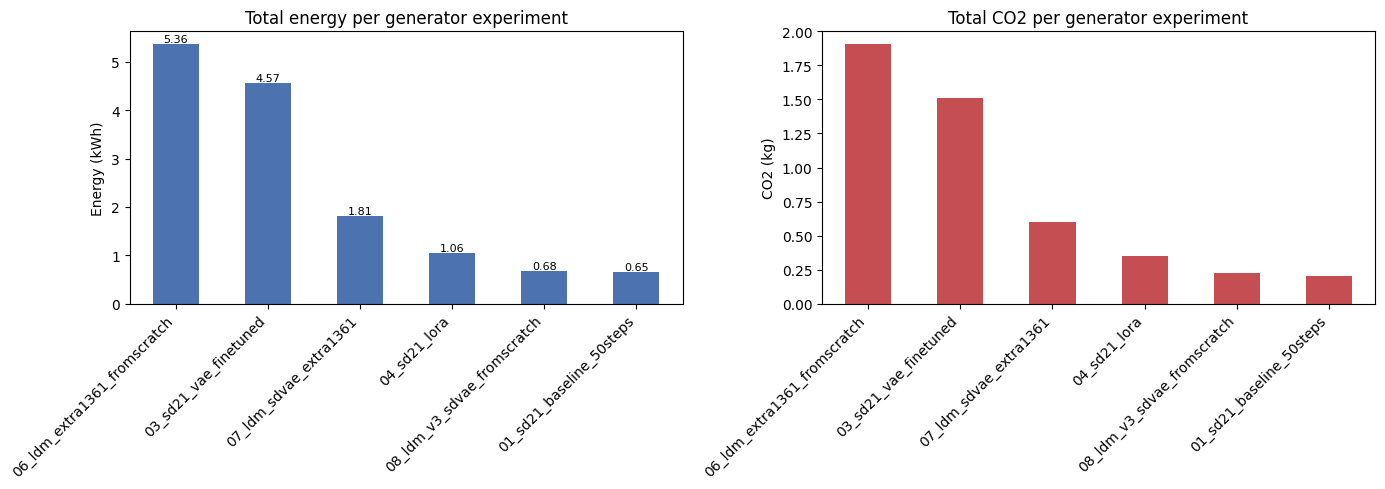

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
totals['energy_kwh'].plot.bar(ax=axes[0], color='#4C72B0')
axes[0].set_ylabel('Energy (kWh)'); axes[0].set_title('Total energy per generator experiment')
for i, v in enumerate(totals['energy_kwh']):
    axes[0].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
totals['co2_kg'].plot.bar(ax=axes[1], color='#C44E52')
axes[1].set_ylabel('CO2 (kg)'); axes[1].set_title('Total CO2 per generator experiment')
for ax in axes:
    ax.set_xlabel(''); ax.tick_params(axis='x', labelrotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')
fig.tight_layout(); fig.savefig(FIGURES / 'generator_energy_co2.png', dpi=110)
gcf = fig

## 3. Where the energy goes — decomposition by phase

phase,generator_training,generation,filtering,validation
generator,,,,
06_ldm_extra1361_fromscratch,4.996,0.241,0.068,0.059
03_sd21_vae_finetuned,3.658,0.534,0.000,0.382
07_ldm_sdvae_extra1361,1.035,0.756,0.014,0.003
04_sd21_lora,0.223,0.755,0.000,0.078
08_ldm_v3_sdvae_fromscratch,0.306,0.265,0.089,0.015
01_sd21_baseline_50steps,0.436,0.199,0.000,0.016


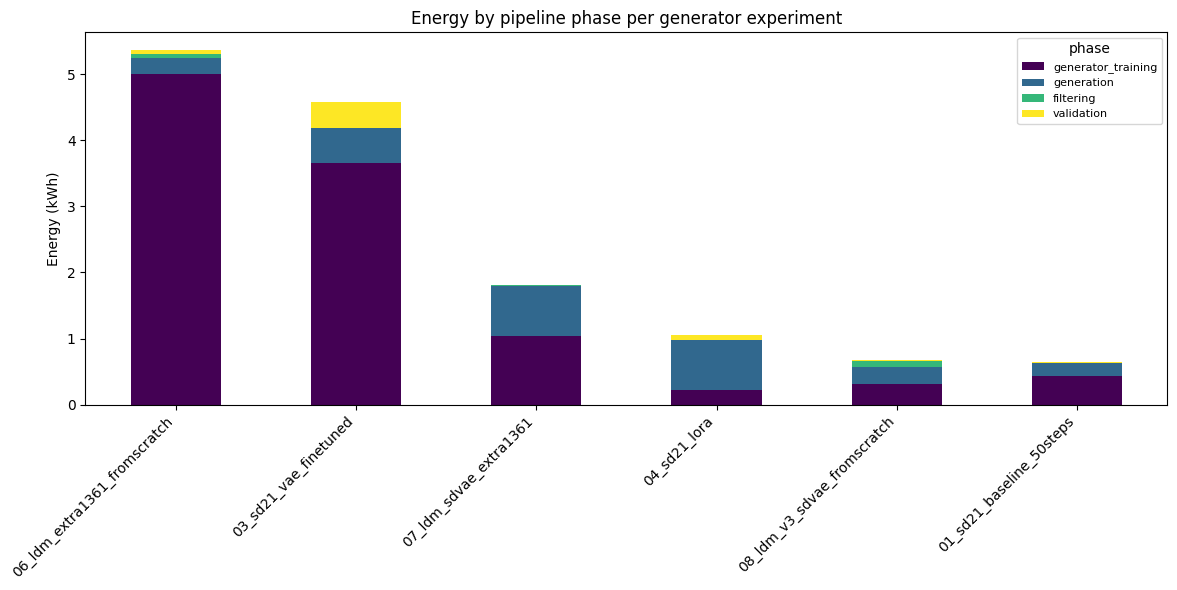

In [4]:
order = ['preprocessing', 'generator_training', 'generation', 'filtering', 'validation']
by_phase = diffusers.groupby(['generator', 'phase'])['energy_kwh'].sum().unstack(fill_value=0.0)
by_phase = by_phase[[p for p in order if p in by_phase.columns]].loc[totals.index]
fig, ax = plt.subplots(figsize=(12, 6))
by_phase.plot.bar(stacked=True, ax=ax, colormap='viridis')
ax.set_ylabel('Energy (kWh)'); ax.set_xlabel('')
ax.set_title('Energy by pipeline phase per generator experiment')
ax.legend(title='phase', fontsize=8); ax.tick_params(axis='x', labelrotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
fig.tight_layout(); fig.savefig(FIGURES / 'generator_energy_by_phase.png', dpi=110)
by_phase.round(3)

## 4. Generation efficiency (where image counts are recorded)

generator
03_sd21_vae_finetuned       0.0000
01_sd21_baseline_50steps    0.0133
04_sd21_lora                0.1386
dtype: float64

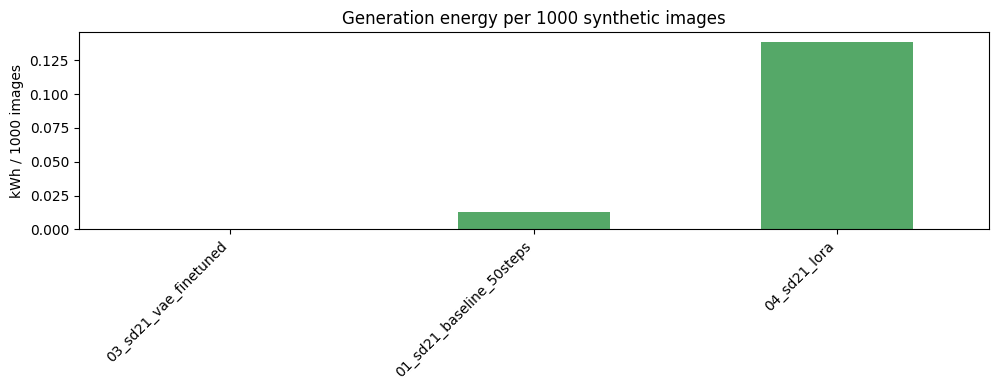

In [5]:
gen = diffusers[(diffusers['phase'] == 'generation') & (diffusers['num_images'] > 0)]
efficiency = (gen.groupby('generator')
              .apply(lambda g: g['energy_kwh'].sum() / g['num_images'].sum() * 1000.0, include_groups=False)
              .sort_values())
if len(efficiency):
    fig, ax = plt.subplots(figsize=(10, 4))
    efficiency.plot.bar(ax=ax, color='#55A868')
    ax.set_ylabel('kWh / 1000 images'); ax.set_xlabel('')
    ax.set_title('Generation energy per 1000 synthetic images')
    ax.tick_params(axis='x', labelrotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')
    fig.tight_layout(); fig.savefig(FIGURES / 'generation_efficiency.png', dpi=110)
efficiency.round(4) if len(efficiency) else 'No per-image counts recorded in the generation phase.'

## 5. Reproducible cost vs. every real attempt

{'actual_project_energy_kwh': 16.515,
 'actual_project_co2_kg': 5.731,
 'actual_project_seconds': 383748.498,
 'canonical_pipeline_energy_kwh': 16.135,
 'canonical_pipeline_co2_kg': 5.455,
 'canonical_pipeline_seconds': 376509.287,
 'retry_and_failure_overhead_kwh': 0.38,
 'n_events_actual': 193,
 'n_events_canonical': 174}

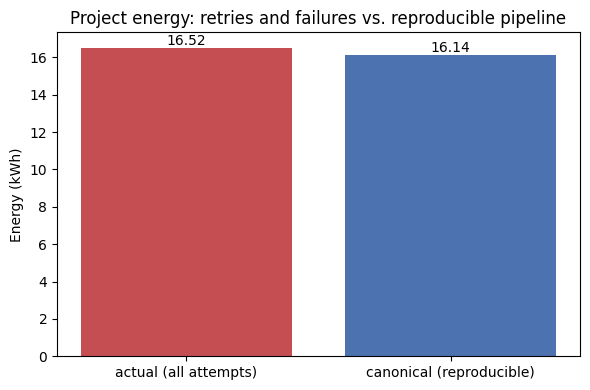

In [6]:
avc = actual_vs_canonical(events)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['actual (all attempts)', 'canonical (reproducible)'],
              [avc['actual_project_energy_kwh'], avc['canonical_pipeline_energy_kwh']],
              color=['#C44E52', '#4C72B0'])
ax.set_ylabel('Energy (kWh)')
ax.set_title('Project energy: retries and failures vs. reproducible pipeline')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}',
            ha='center', va='bottom')
fig.tight_layout(); fig.savefig(FIGURES / 'actual_vs_canonical.png', dpi=110)
{k: (round(v, 3) if isinstance(v, float) else v) for k, v in avc.items()}

## Notes

- Energy, CO2 and time come from the deduplicated canonical registry; the experiment-08 step-count
  sweep is folded into its base generator.
- `actual` includes every real attempt (failures and retries); `canonical` is the reproducible
  pipeline. Their difference is the retry-and-failure overhead.
- CodeCarbon values are estimates, not wall-socket measurements, and efficiency is never used as a
  generator-selection metric.